# Importing Libraries

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix


# Load Data

In [43]:
def load_heart_data():
    path = "titanic.csv"
    df = pd.read_csv(path)
    return df

df = load_heart_data()
print("Shape:", df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Target Distribution

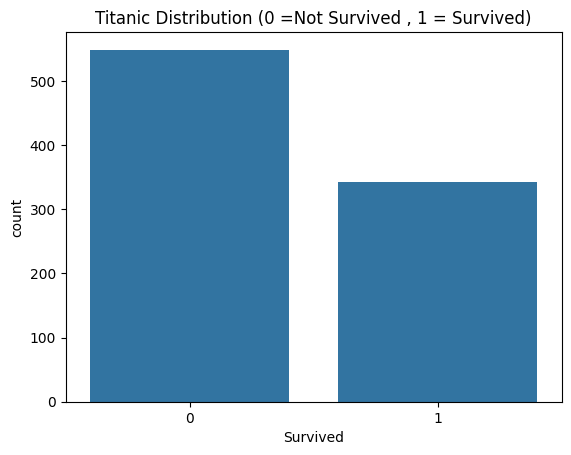

In [44]:
sns.countplot(x='Survived', data=df)
plt.title("Titanic Distribution (0 =Not Survived , 1 = Survived)")
plt.show()

# Missing Values

In [45]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


# Preprocessing

In [46]:


df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Fare'] = df['Fare'].fillna(df['Fare'].mean())


df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)


le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# 4. Split data
X = df.drop('Survived', axis=1)
y = df['Survived']


In [47]:
print(df.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


# spliting Data

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [49]:
smote = SMOTE(random_state=42)

X_train_smote,y_train_smote = smote.fit_resample(X_train,y_train)


print("Before SMOTE:")
print(y_train.value_counts())

print("After SMOTE:")
print((y_train_smote).value_counts())


Before SMOTE:
Survived
0    392
1    231
Name: count, dtype: int64
After SMOTE:
Survived
1    392
0    392
Name: count, dtype: int64


# Random Forest Model

In [50]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train_smote,y_train_smote)
rf_preds = rf_model.predict(X_test)

# Bagging

In [51]:
from sklearn.utils import resample
from scipy.stats import mode
def bagger_fit_predict(model_fns, X_train, y_train, X_test, n_estimators=15):
    all_preds = []
    for fn in model_fns:
        for _ in range(n_estimators):
            # Bootstrap sample
            X_bs, y_bs = resample(X_train, y_train, replace=True)
            # Build model
            model = fn()
            # Fit model
            model.fit(X_bs, y_bs)
            # Predict test set
            preds = model.predict(X_test)
            all_preds.append(preds)

    all_preds = np.array(all_preds)  # shape → (models*estimators, n_samples)
    final_preds = mode(all_preds, axis=0).mode  # majority vote
    return final_preds.ravel()

In [52]:
model_list = [
    lambda: DecisionTreeClassifier(max_depth=5),
    lambda: KNeighborsClassifier(n_neighbors=5),
    lambda: LogisticRegression(max_iter=50)
]
bagger_preds = bagger_fit_predict(
    model_fns=model_list,
    X_train=X_train_smote,
    y_train=y_train_smote,
    X_test=X_test,
    n_estimators=15
)

/home/awais-iftikhar/Desktop/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 50 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=50).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/awais-iftikhar/Desktop/ML/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 50 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=50).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stab

# Accuracy Score

In [53]:
print('Accuracy for Random Forest',accuracy_score(y_test,bagger_preds))
print('Accuracy for Bagging',accuracy_score(y_test,bagger_preds))

Accuracy for Random Forest 0.7985074626865671
Accuracy for Bagging 0.7985074626865671


# Report for Random Forest

In [54]:
print("Classification Report (Random Forest):")
print(classification_report(y_test, rf_preds))

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.81      0.86      0.84       157
           1       0.78      0.72      0.75       111

    accuracy                           0.80       268
   macro avg       0.80      0.79      0.79       268
weighted avg       0.80      0.80      0.80       268



# Report for Custom Bagging

In [55]:
print("Classification Report (Custom Bagger):")
print(classification_report(y_test, bagger_preds))

Classification Report (Custom Bagger):
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       157
           1       0.77      0.74      0.75       111

    accuracy                           0.80       268
   macro avg       0.79      0.79      0.79       268
weighted avg       0.80      0.80      0.80       268



In [56]:
print(confusion_matrix(y_test, rf_preds))

[[135  22]
 [ 31  80]]
